# Tabla de contenidos

* [Objetivo](#Objetivo)
* [Importación de librerías](#Importación-de-librerías)
* [Carga de los datos](#Carga-de-los-datos)
* [Exploración de los datos](#Exploración-de-los-datos)
	* [Conclusión del análisis exploratorio](#Conclusión-del-análisis-exploratorio)
* [Depuración de los datos](#Depuración-de-los-datos)
	* [Fase I: Detección de outliers](#Fase-I:-Detección-de-outliers)
	* [Fase II: Detección datos perdidos](#Fase-II:-Detección-datos-perdidos)
		* [Tratamiento de valores perdidos - eliminación](#Tratamiento-de-valores-perdidos---eliminación)
		* [Tratamiento de valores perdidos - imputación](#Tratamiento-de-valores-perdidos---imputación)
			* [Variables cuantitativas con datos perdidos.](#Variables-cuantitativas-con-datos-perdidos.)
			* [Variables categóricas con datos perdidos.](#Variables-categóricas-con-datos-perdidos.)
		* [Imputación por el vecino más cercano](#Imputación-por-el-vecino-más-cercano)
* [Transformación de los datos](#Transformación-de-los-datos)
* [Selección de características](#Selección-de-características)
* [Conjunto test](#Conjunto-test)
	* [Carga del conjunto de datos](#Carga-del-conjunto-de-datos)
	* [Exploración de los datos](#Exploración-de-los-datos)
	* [Depuración de los datos](#Depuración-de-los-datos)
	* [Transformación de los datos](#Transformación-de-los-datos)
	* [Selección de características](#Selección-de-características)
* [APRENDIZAJE NO SUPERVISADO](#APRENDIZAJE-NO-SUPERVISADO)
	* [Asociación](#Asociación)
	* [Clustering](#Clustering)
* [Conclusiones](#Conclusiones)
* [APRENDIZAJE SUPERVISADO](#APRENDIZAJE-SUPERVISADO)
	* [Clasificador bayesiano](#Clasificador-bayesiano)
	* [Clasificador Árboles de decisión](#Clasificador-Árboles-de-decisión)
	* [Clasificador $k$-NN](#Clasificador-$k$-NN)
	* [Clasificador Perceptrón Multicapa](#Clasificador-Perceptrón-Multicapa)
	* [Autoencoder](#Autoencoder)
* [Conclusiones](#Conclusiones)


<h1 style="color:#dd6d10"><center> ANALÍTICA DE BIG DATA <br> <br> Cuaderno de trabajo - Evaluación</h1></center>

Este cuaderno ofrece la aplicación de distintas técnicas de aprendizaje automático para realizar predicciones sobre la conocida base de datos *titanic*. Para más información sobre este conjunto de datos se puede consultar *Report on the Loss of the 'Titanic' (S.S.) (1990), British Board of Trade Inquiry Report\_(reprint), Gloucester, UK: Allan Sutton Publishing*.

Se llevará a cabo un análisis del conjunto de datos, así como la predicción de la variable explicada.

La variable explicada o dependiente (atributo *survived*) indica si la persona sobrevivió o no al hundimiento del Titacnic. El objetivo es encontrar alguna relación entre los atributos (variables independientes) y la probabilidad de que un pasajero sobreviva o no al naufragio (variable dependiente). Por ejemplo, supervivencia por edad, sexo, clase, etc.

# Objetivo

Predecir, con las técnicas de aprendizaje automático, si un pasajero sobrevive o no al hundimiento del Titanic. Es decir, dado unos valores de los atributos para un cierto pasajero, los modelos deben predecir el valor 0 o 1 para la variable *survived*.

# Importación de librerías

In [98]:
# Instalar seaborn
!pip install seaborn
!pip install apyori missingno

# pandas
import pandas as pd
from sklearn.metrics import mean_squared_error
import math

# numpy, matplotlib, seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy import stats

# machine learning
from apyori import apriori
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

import missingno as msno
import random

from warnings import filterwarnings
filterwarnings('ignore')

# Carga de los datos

Descargar los conjuntos de entrenamiento y test disponibles en el campus virtual.

In [99]:
titanic = pd.read_csv('Conjunto_de_datos_20260119/dataset.csv')
titanic

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [100]:
titanicRealTest = pd.read_csv('Conjunto_de_datos_20260119/newData.csv')
titanicRealTest

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# Análisis exploratorio de datos (EDA)

Antes de construir un modelo predictivo, es importante realizar una exploración descriptiva de los datos que se van a usar. Este proceso ayuda a comprender qué información contiene cada variable, así como a detectar posibles errores: tipos de datos incorrectos, valores perdidos, valores inconsistentes,etc.

Este análisis inicial puede dar pistas sobre las variables. Para este conjunto de datos se podrían obtener respuestas a preguntas como:

¿Qué porcentaje hubo de supervivivientes?

¿Qué tipo de personas se salvaron: clase en la que viajaban, puerto en el que embarcaron, si tenían hijos a bordo, sexo, edad,...?

Las características de este conjunto de datos se describen a continuación:



| Variable	| Definición | Valores |
|:---------:|:----------:|---:|
| survived	| Sobrevive	 | 0 = No, 1 = Sí |
| pclass	| Clase      | 1 = 1ª, 2 = 2ª, 3 = 3ª| 
| name      | Nombre pasajero |       |
| sex       | 	Sexo     | male=Hombre, female=Mujer |
| age       |	Edad en años|	|
| sibsp     |	# de hermanos/cónyuges a bordo del Titanic | Sibling = hermano, hermana, hermanastro, hermanastra|
|           |            | Spouse = esposo, esposa (se ignoraron amantes y prometidos) |
| parch	    | # de padres/hijos a bordo del Titanic | Parent = madre, padre |
|           |            | Child = hija, hijo, hijastra, hijastro |
|           |                  | Algunos niños viajaron solo con una niñera, por lo tanto parch=0 para ellos. |	
| ticket	| Número  ticket |     |
| fare	    | Tarifa pasajero |    |	
| cabin	    | Número de cabina |     |	
| embarked	| Puerto de embarque |	C = Cherbourg, Q = Queenstown, S = Southampton |



Nominales: survival, name, sex, ticket, cabin, embarked

Ordinal: pclass

Discretos: sibsp, parch

Continuos: age, fare

## Análisis descriptivo de datos

Realizar un análisis descriptivo de los datos en este conjunto: medidas de frecuencia, tendencia, dispersión, posición y distribución. A continuación se muestran algunos ejemplos de este estudio.

In [101]:
# permite obtener el numero de filas y columnas
print(titanic.shape)

(891, 11)


In [102]:
# Muestra las primeros 5 filas del dataset por defecto
print(titanic.head())

   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age  sibsp  parch            ticket     fare cabin embarked  
0    male  22.0      1      0         A/5 21171   7.2500   NaN        S  
1  female  38.0      1      0          PC 17599  71.2833   C85        C  
2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S  
3  female  35.0      1      0            113803  53.1000  C123        S  
4    male  35.0      0      0            373450   8.0500   NaN        S  


In [103]:
# genera un resumen estadístico de las columnas numéricas
print(titanic.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


La información que ofrece para variables cuantitativas:


count: número de términos por columnas

mean: valor medio de la columna

std: desviación estándar de la columna

max: valor máximo de la columna

min: valor mínimo de la columna

límite de cada uno de los cuartiles


Y para variables categóricas:

unique: número de objetos diferentes por columnas

top: los datos más frecuentes que se producen

freq: el número de veces que aparece el objeto *top* en la columna


Algunos valores en la tabla se muestran como NaN, esto se debe a que esta métrica estadística en particular no se puede calcular para ese tipo específico de datos.

Se puede obtener más información con _include = all_.

In [104]:
titanic.describe(include = "all")

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Análisis de pasajeros por clase (Pclass)

En este paso se realizará un **agrupamiento de los datos del Titanic** según la clase del pasajero (`pclass`), con el objetivo de conocer **cuántos pasajeros pertenecen a cada clase**.

### Objetivo
- Identificar la distribución de pasajeros entre 1ª, 2ª y 3ª clase.
- Detectar posibles **desbalances en el dataset**.
- Obtener una visión inicial del perfil socioeconómico de los pasajeros.

### Descripción del proceso
- Se utiliza `groupby('pclass')` para agrupar los registros por clase.
- Se aplica `size()` para contar el número total de filas en cada grupo.

### Resultado esperado
El resultado será una serie que muestra:
- Cada valor único de `pclass`
- El número total de pasajeros asociados a cada clase

In [105]:
titanic.groupby('pclass').size()

pclass
1    216
2    184
3    491
dtype: int64

### Distribución de pasajeros por clase

A partir del agrupamiento por la variable `pclass`, se observa la siguiente
distribución de pasajeros:

- **1ª clase:** 216 pasajeros
- **2ª clase:** 184 pasajeros
- **3ª clase:** 491 pasajeros

Este resultado evidencia un **desbalance significativo**, donde la mayoría
de los pasajeros pertenecían a la tercera clase.  
La variable `pclass` se considera un **factor clave** para análisis posteriores,
especialmente en estudios de supervivencia y modelos predictivos.

## Análisis de pasajeros por cabina (Cabin)

Se realiza un agrupamiento de los pasajeros según la variable `cabin`
para identificar cuántos pasajeros están asociados a cada cabina.

### Consideraciones importantes
- La variable `cabin` presenta una **alta cantidad de valores nulos**.
- Solo se contabilizan las cabinas registradas (los valores `NaN` se excluyen).
- La mayoría de las cabinas aparecen con un único pasajero.

In [106]:
titanic.groupby('cabin').size()

cabin
A10    1
A14    1
A16    1
A19    1
A20    1
      ..
F33    3
F38    1
F4     2
G6     4
T      1
Length: 147, dtype: int64

## Agrupación por letra de cabina

Con el fin de reducir la complejidad de la variable `cabin`, se extrae
la **primera letra de la cabina**, la cual representa la sección o cubierta
del barco.

Posteriormente, se agrupan los pasajeros según esta nueva variable
(`cabin_letter`) para conocer cuántos pasajeros pertenecen a cada sección.

Este enfoque permite **reducir la dimensionalidad**, mejorar la
interpretabilidad de los datos y preparar la variable para
análisis exploratorio y modelos predictivos.

In [107]:
titanic['cabin_letter'] = titanic['cabin'].str[0]
titanic.groupby('cabin_letter').size()

cabin_letter
A    15
B    47
C    59
D    33
E    32
F    13
G     4
T     1
dtype: int64

### Conclusión
Debido a la alta proporción de valores faltantes y la gran cantidad de
categorías únicas, la variable `cabin` no es adecuada para un uso directo
en modelos predictivos sin un proceso previo de transformación o limpieza.

## Supervivencia por clase del pasajero

Se realiza un análisis conjunto de las variables `survived` y `pclass`
para evaluar la relación entre la clase del pasajero y la probabilidad
de supervivencia.

Los resultados muestran que los pasajeros de **primera clase presentan
una mayor tasa de supervivencia**, mientras que la **tercera clase
concentra la mayor cantidad de fallecimientos**.

Este análisis evidencia una **fuerte dependencia entre el nivel
socioeconómico y la supervivencia**.

In [108]:
titanic.groupby(['survived', 'pclass']).size()

survived  pclass
0         1          80
          2          97
          3         372
1         1         136
          2          87
          3         119
dtype: int64

In [109]:
titanic.groupby(['survived', 'pclass']).size().unstack()

pclass,1,2,3
survived,,,
0,80,97,372
1,136,87,119


## Supervivencia por edad (considerando valores nulos)

El análisis de supervivencia por edad se realiza a partir del agrupamiento
de las variables `survived` y `age`. Es importante destacar que la variable
`age` presenta valores nulos (`NaN`) en el dataset.

Por defecto, el método `groupby` **excluye los registros con edad no
informada**, por lo que el análisis únicamente considera pasajeros con
edad conocida. Esto puede generar una **pérdida de información** y
posibles sesgos en la interpretación de los resultados.

In [110]:
titanic.groupby(['survived', 'age']).size()

survived  age 
0         1.0     2
          2.0     7
          3.0     1
          4.0     3
          6.0     1
                 ..
1         58.0    3
          60.0    2
          62.0    2
          63.0    2
          80.0    1
Length: 142, dtype: int64

In [111]:
titanic['age'].isna().sum()

np.int64(177)

In [112]:
pd.isna(titanic['age'])

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: age, Length: 891, dtype: bool

## Valores únicos de la variable Embarked

Se identifican los valores únicos de la variable `embarked` para conocer
los distintos puertos de embarque presentes en el dataset.

El resultado muestra tres categorías válidas (`S`, `C`, `Q`) y la presencia
de valores nulos (`NaN`), correspondientes a registros sin información
de puerto de embarque.

In [113]:
titanic['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

## Matriz de correlación entre variables cuantitativas

Se calcula la matriz de correlación utilizando el coeficiente de Pearson
para evaluar la relación lineal entre las variables numéricas del dataset.

El análisis permite identificar qué variables presentan una mayor
asociación con la variable objetivo (`survived`) y detectar posibles
relaciones redundantes entre variables explicativas.

Este paso es clave para la selección de variables y la comprensión
inicial del comportamiento de los datos antes de aplicar modelos
predictivos.

In [114]:
titanic.corr(method='pearson', numeric_only=True) #Variables cuantitativas

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## Distribución de variables cuantitativas

Se generan histogramas para todas las variables numéricas del dataset
con el objetivo de analizar su distribución, dispersión y posibles
valores atípicos.

Este análisis permite identificar asimetrías, rangos predominantes y
características relevantes de cada variable, siendo un paso fundamental
del análisis exploratorio de datos (EDA) previo a la preparación y
modelado de los datos.

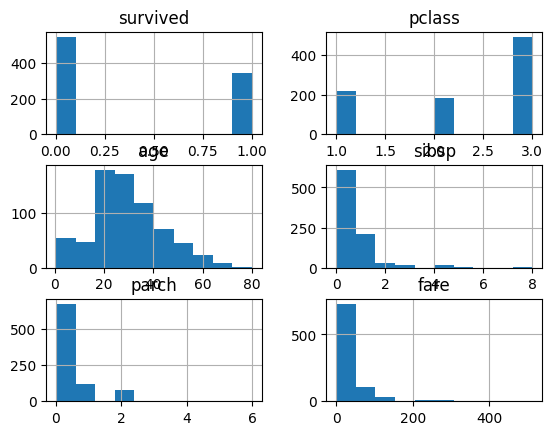

In [115]:
titanic.hist()
plt.show()

## Análisis de asimetría de variables cuantitativas

Se calcula el coeficiente de asimetría (skewness) para las variables
numéricas del dataset con el objetivo de evaluar la forma de sus
distribuciones.

La asimetría permite identificar variables con distribuciones sesgadas,
lo que resulta clave para la detección de outliers y la decisión sobre
posibles transformaciones de los datos antes de su uso en modelos
predictivos.

In [116]:
asimetria = titanic.skew(numeric_only=True)
asimetria

survived    0.478523
pclass     -0.630548
age         0.389108
sibsp       3.695352
parch       2.749117
fare        4.787317
dtype: float64

Si el valor resultante para la asimetría está por encima de +1 o por debajo de -1, los datos están muy sesgados. Si está entre +0.5 y -0.5, están sesgados moderadamente. Si el valor es 0, entonces los datos son simétricos.

¿Se puede eliminar alguna variable a partir del análisis exploratorio llevado a cabo?

## Eliminación de variables a partir del EDA

A partir del análisis exploratorio de los datos, se identificaron algunas
variables que presentan una alta proporción de valores faltantes, elevada
cardinalidad o bajo aporte informativo en su forma original.

En particular, variables como `cabin`, `ticket` y `name` no resultan
adecuadas para su uso directo, por lo que pueden ser eliminadas o
transformadas sin pérdida significativa de información. Por el contrario,
variables como `pclass`, `sex`, `fare` y `embarked` presentan una relación
relevante con la supervivencia y deben ser conservadas.

Estas decisiones permiten simplificar el dataset y mejorar la calidad de
los datos para análisis posteriores y modelos predictivos.

In [117]:
titanic['sex'].unique()

array(['male', 'female'], dtype=object)

In [118]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

## Detección de outliers

Aplicar técnicas para detectar los valores sospechosos de ser atípicos: método basado en la desviación típica, rango intercuartílico y diagrama de caja.


<Axes: >

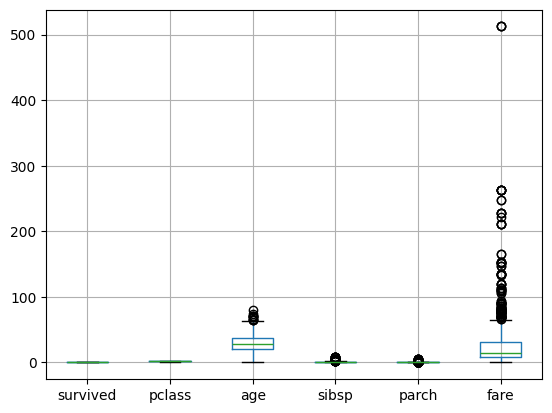

In [119]:
titanic.boxplot()

<Axes: >

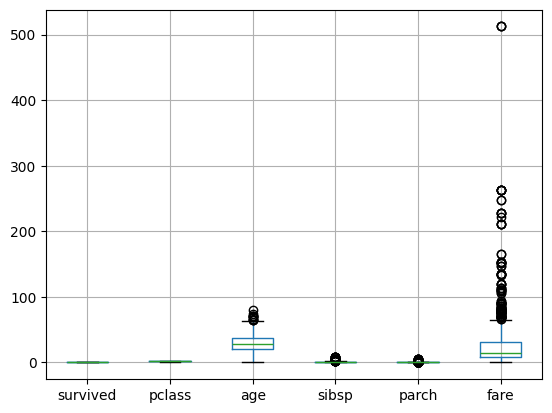

In [120]:
titanic.boxplot()

## ¿Qué ocurre con la variable *fare*?

La variable **`fare`** presenta una **alta dispersión** y una **asimetría positiva muy marcada**.  
Al analizar el diagrama de caja (`titanic.boxplot()`), se observa que:

- La mayor concentración de valores se encuentra por debajo de **50**.
- Existen valores **extremadamente altos** que alcanzan aproximadamente **500**, correspondientes a **muy pocos registros**.
- Estos valores aparecen claramente como **outliers**, alejados del rango intercuartílico.

Este comportamiento indica una gran variabilidad en el precio del pasaje, asociada principalmente a la clase del pasajero, y sugiere que dichos valores extremos pueden **distorsionar análisis estadísticos y modelos predictivos** si no se tratan adecuadamente.

---

## ¿Y el resto de las variables?

### 🔹 *age*
- Presenta algunos **valores atípicos**, especialmente en edades avanzadas.
- La dispersión es **moderada** y significativamente menor que en `fare`.
- La mayoría de los valores se concentran en rangos de edad habituales.

### 🔹 *sibsp* y *parch*
- Ambas variables muestran **outliers**, pero en **muy baja proporción**.
- La mayoría de los pasajeros viajan con **0 o pocos familiares**.
- Los valores extremos representan casos poco frecuentes y tienen **impacto limitado** en la distribución general.



## Detección datos perdidos

Hay que comprobar que el conjunto de datos esté completo, es decir, hay que comprobar que no haya datos perdidos.
 
 ¿Qué variables cuentan con datos perdidos en este conjunto de datos?
  
  
  ¿Qué ocurre con las cabinas de los pasajeros de tercera clase?
  
  
  ¿Existe algún pasajero de primera clase que no tenga asignada cabina?
  
 
  ¿Se establece NaN a los datos perdidos?

In [121]:
titanic.describe().loc['count']

survived    891.0
pclass      891.0
age         714.0
sibsp       891.0
parch       891.0
fare        891.0
Name: count, dtype: float64

In [122]:
titanic.count()

survived        891
pclass          891
name            891
sex             891
age             714
sibsp           891
parch           891
ticket          891
fare            891
cabin           204
embarked        889
cabin_letter    204
dtype: int64

In [123]:
titanic.isnull().sum()

survived          0
pclass            0
name              0
sex               0
age             177
sibsp             0
parch             0
ticket            0
fare              0
cabin           687
embarked          2
cabin_letter    687
dtype: int64

In [124]:
titanic[titanic['age'].isnull()]

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,NaN
17,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,NaN
19,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,NaN
26,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,NaN
28,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
859,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,NaN
863,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,NaN
868,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,NaN
878,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,NaN


La visualización `msno.bar(titanic)` permite analizar la completitud de los datos,
mostrando el número de valores no nulos por variable y facilitando la identificación
de columnas con alta proporción de datos faltantes.

<Axes: >

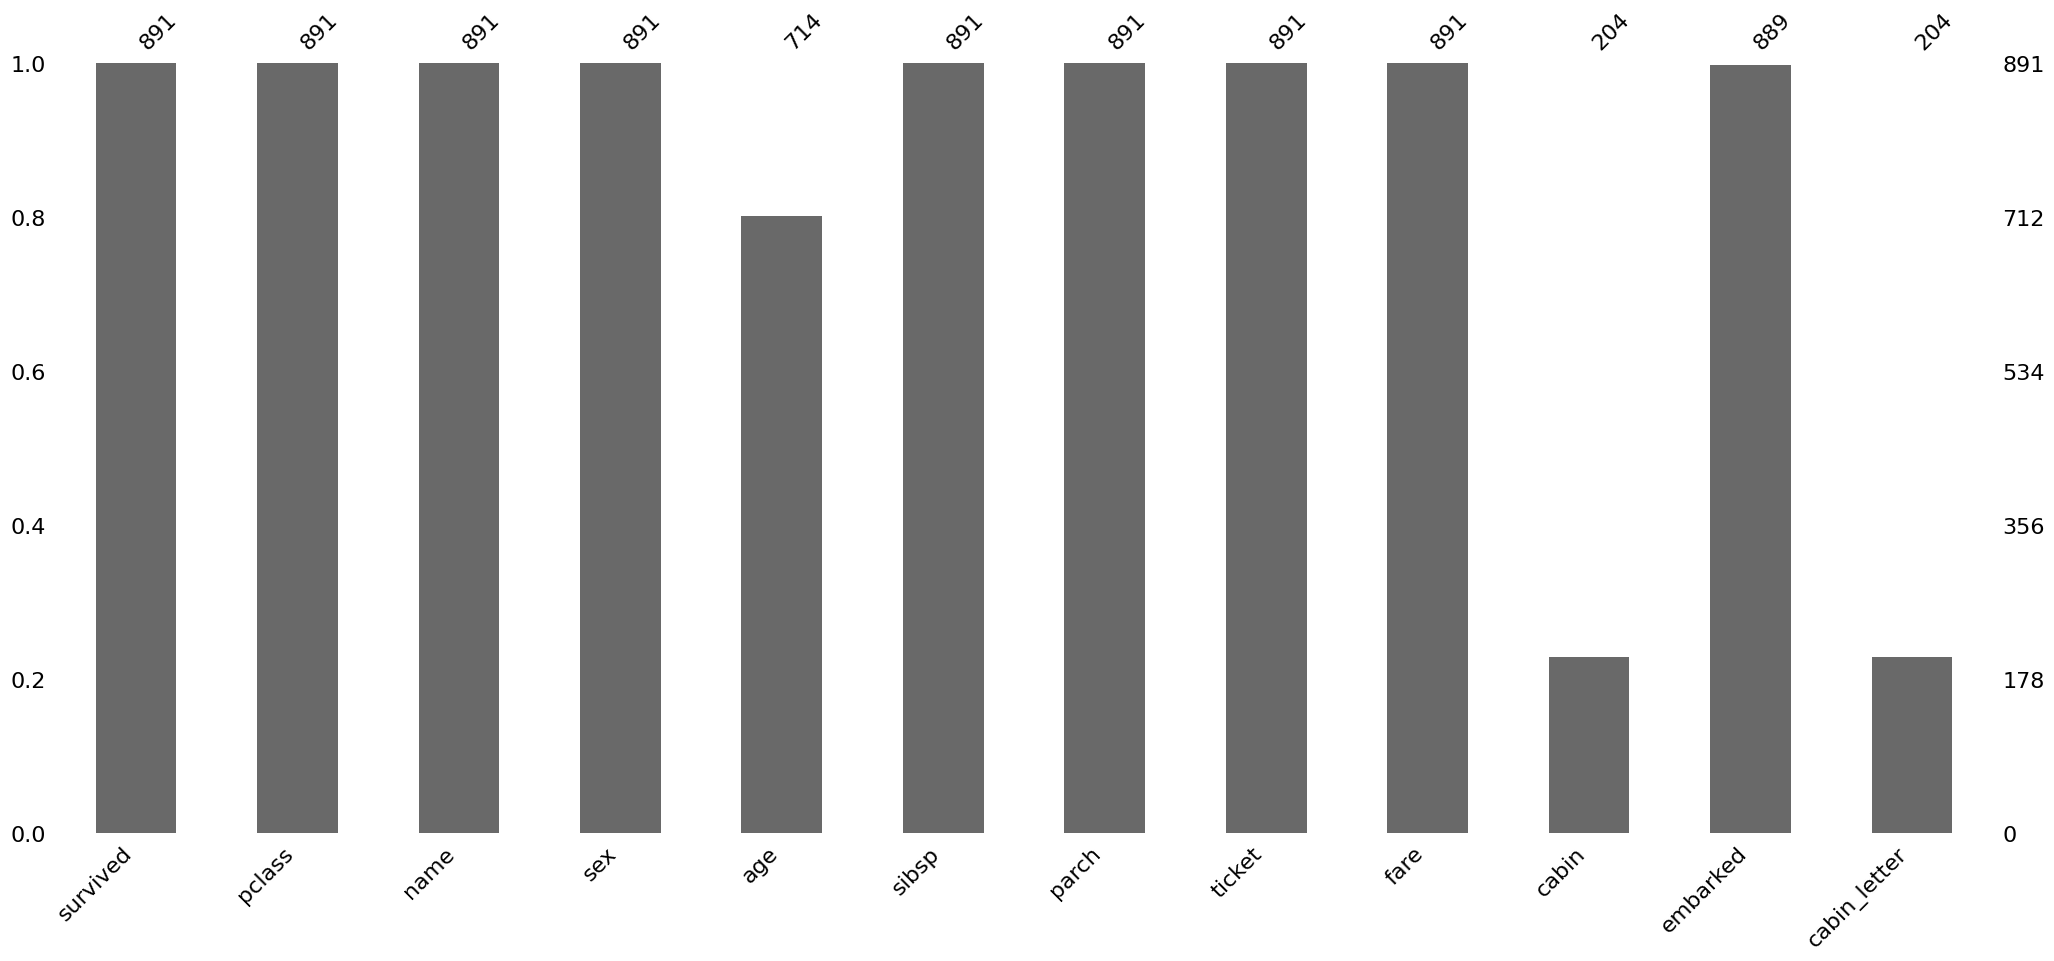

In [125]:
msno.bar(titanic)

Esta operación ordena el dataset según la variable `cabin` en orden ascendente,
ubicando los valores faltantes al final, lo que facilita el análisis visual
de la distribución y completitud de dicha variable.

In [126]:
titanic.sort_values("cabin", ascending = True, na_position ='last')

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
583,0,1,"Ross, Mr. John Hugo",male,36.0,0,0,13049,40.1250,A10,C,A
475,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S,A
556,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6000,A16,C,A
284,0,1,"Smith, Mr. Richard William",male,NaN,0,0,113056,26.0000,A19,S,A
599,1,1,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,56.9292,A20,C,A
...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,NaN
885,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,NaN
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,NaN
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN


Se procede a identificar y filtrar los registros cuyo valor en la variable `cabin` es nulo,
permitiendo analizar el perfil de los pasajeros que no tienen cabina asignada.

In [127]:
cabin_ord=titanic['cabin'].isnull()
titanic[cabin_ord]

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,NaN
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,NaN
885,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,NaN
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,NaN
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN


Se calcula la frecuencia de cada categoría de la variable `embarked`,
mostrando cuántos pasajeros embarcaron en cada puerto y excluyendo los valores nulos.

In [128]:
print(titanic.loc[:,'embarked'].value_counts())

embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Se filtra los registros cuyo valor en la variable `embarked` es nulo,
permitiendo analizar el perfil de los pasajeros con información de embarque faltante.

In [129]:
titanic[titanic['embarked'].isnull()]

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
61,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,B
829,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,B


Se filtra el dataset para mostrar únicamente los pasajeros de primera clase,
facilitando el análisis comparativo frente a otras clases del barco.

In [130]:
titanic[(titanic['pclass']) == 1]

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,E
11,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,C
23,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S,A
...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,D
872,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,B
879,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,C
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B


## Conclusión del análisis exploratorio

### 1. Calidad y completitud de los datos

El conjunto de datos presenta **valores faltantes relevantes**, principalmente en las siguientes variables:

- **`cabin`**: muestra una proporción muy elevada de valores nulos (687), lo que dificulta su uso directo.
- **`age`**: contiene valores faltantes en una proporción moderada (177).
- **`embarked`**: presenta muy pocos valores faltantes (2).

Por el contrario, variables como **`survived`**, **`sex`**, **`pclass`** y **`fare`** se encuentran completamente registradas.

A partir de esto, se justifica:
- La eliminación o transformación de la variable `cabin`.
- La imputación de los valores faltantes en `age` y `embarked`.

### 2. Distribución de pasajeros y desbalance de clases

Se observa un **desbalance claro en la variable `pclass`**, donde la mayoría de los pasajeros pertenecen a la **3ª clase**, seguida de la 1ª y 2ª clase.

Este comportamiento refleja diferencias socioeconómicas marcadas entre los pasajeros y puede influir de forma significativa en la variable objetivo.

### 3. Análisis de la variable objetivo: `survived`

La variable **`survived`** no presenta una distribución uniforme. Al analizarla en conjunto con otras variables se identifican patrones claros:

- Los pasajeros de **1ª clase** presentan una tasa de supervivencia notablemente mayor.
- Los pasajeros de **3ª clase** concentran la mayor cantidad de fallecimientos.

Esto sugiere que la clase social fue un factor determinante en la probabilidad de supervivencia.

### 4. Variables numéricas y presencia de valores atípicos

El análisis gráfico y estadístico revela que:

- **`fare`** es la variable con mayor dispersión y una **asimetría positiva muy pronunciada**, con valores extremos que se alejan considerablemente del resto de los datos.
- **`age`** presenta algunos valores atípicos, aunque su impacto es menor.
- **`sibsp`** y **`parch`** también muestran outliers, pero en cantidades reducidas y con escasa influencia en la distribución general.

Los valores de asimetría calculados confirman estos hallazgos, destacando especialmente el comportamiento de `fare`.

### 5. Análisis de variables categóricas

- **`sex`**:
  - Contiene únicamente dos categorías (`male` y `female`).
  - Es una variable altamente informativa en relación con la supervivencia.
  - Resulta adecuada para una **codificación binaria**.

- **`embarked`**:
  - Presenta tres categorías (`S`, `C` y `Q`).
  - Tiene pocos valores faltantes.
  - Requiere imputación y posterior codificación (por ejemplo, one-hot encoding).


## **Variables a eliminar o transformar**:
- `cabin`, debido a la alta proporción de valores faltantes.

## Conclusión general

El análisis exploratorio permitió comprender en profundidad el dataset, identificar problemas de calidad de datos, detectar patrones relevantes y definir transformaciones necesarias. Estas decisiones mejoran tanto la interpretabilidad de los datos como la calidad de los modelos predictivos que se construyan posteriormente, estableciendo una base sólida para el proceso de machine learning.

# Creación X e Y

En el conjunto de datos es necesario separar la variable dependiente (variable a predecir Y) de las variables independientes (variables predictoras X).

In [131]:
#The X and Y data sets are created.

X = titanic.drop(columns=['survived'])        #features
Y=  titanic['survived']                       #target

print(X)
print(Y)

     pclass                                               name     sex   age  \
0         3                            Braund, Mr. Owen Harris    male  22.0   
1         1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
2         3                             Heikkinen, Miss. Laina  female  26.0   
3         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
4         3                           Allen, Mr. William Henry    male  35.0   
..      ...                                                ...     ...   ...   
886       2                              Montvila, Rev. Juozas    male  27.0   
887       1                       Graham, Miss. Margaret Edith  female  19.0   
888       3           Johnston, Miss. Catherine Helen "Carrie"  female   NaN   
889       1                              Behr, Mr. Karl Howell    male  26.0   
890       3                                Dooley, Mr. Patrick    male  32.0   

     sibsp  parch            ticket    

# División de los datos

El objetivo de un modelo es predecir la variable respuesta en observaciones futuras o en observaciones a las que el modelo no se ha enfrentado con anterioridad. El error medido sobre el conjunto de entrenamiento (predice observaciones conocidas) puede ayudar a comprender cómo aprende el modelo, pero no constituyen una estimación realista de su comportamiento. El error de entrenamiento es demasiado optimista. 

Para obtener una estimación más precisa el error se mide sobre predicciones realizadas cuando se aplica el modelo al conjunto de prueba. Por lo tanto, antes de construir el modelo, utilizamos Hold-out para dividir el conjunto de datos inicial en dos subconjuntos: el de entrenamiento y el de prueba. De esta manera, el subconjunto de entrenamiento se utilizará para que los algoritmos aprendan y el de prueba para predecir y medir el rendimiento de los modelos.

In [132]:
from sklearn.model_selection import train_test_split

# División del conjunto en entramiento y test para realizar las predicciones
test_size = 0.30 #O 0.20
seed = 100
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [133]:
X_train

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
69,3,"Kink, Mr. Vincenz",male,26.0,2,0,315151,8.6625,NaN,S,NaN
85,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,3,0,3101278,15.8500,NaN,S,NaN
794,3,"Dantcheff, Mr. Ristiu",male,25.0,0,0,349203,7.8958,NaN,S,NaN
161,2,"Watt, Mrs. James (Elizabeth ""Bessie"" Inglis Mi...",female,40.0,0,0,C.A. 33595,15.7500,NaN,S,NaN
815,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0000,B102,S,B
...,...,...,...,...,...,...,...,...,...,...,...
855,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,NaN
871,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,D
835,1,"Compton, Miss. Sara Rebecca",female,39.0,1,1,PC 17756,83.1583,E49,C,E
792,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.5500,NaN,S,NaN


In [134]:
X_test

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_letter
205,3,"Strom, Miss. Telma Matilda",female,2.0,0,1,347054,10.4625,G6,S,G
44,3,"Devaney, Miss. Margaret Delia",female,19.0,0,0,330958,7.8792,NaN,Q,NaN
821,3,"Lulic, Mr. Nikola",male,27.0,0,0,315098,8.6625,NaN,S,NaN
458,2,"Toomey, Miss. Ellen",female,50.0,0,0,F.C.C. 13531,10.5000,NaN,S,NaN
795,2,"Otter, Mr. Richard",male,39.0,0,0,28213,13.0000,NaN,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...
111,3,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN
730,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S,B
105,3,"Mionoff, Mr. Stoytcho",male,28.0,0,0,349207,7.8958,NaN,S,NaN
479,3,"Hirvonen, Miss. Hildur E",female,2.0,0,1,3101298,12.2875,NaN,S,NaN


In [136]:
Y_train

69     0
85     1
794    0
161    1
815    0
      ..
855    1
871    1
835    1
792    0
520    1
Name: survived, Length: 623, dtype: int64

In [137]:
Y_test

205    0
44     1
821    1
458    1
795    0
      ..
111    0
730    1
105    0
479    1
277    0
Name: survived, Length: 268, dtype: int64

# Depuración de los datos

## Fase I: Eliminación de variables

In [91]:
+635210

635210

## Fase II: Tratamiento de outliers

Aplicar técnicas para detectar los valores sospechosos de ser atípicos: método basado en la desviación típica, rango intercuartílico y diagrama de caja.


In [92]:
# Cálculo rango intercuartílico
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:
# Eliminación outliers 
X_train_out = X_train[~((X_train < (Q1 - 1.5 * IQR)) |(X_train > (Q3 + 1.5 * IQR))).any(axis=1)]
X_train_out.shape

## Fase III: Tratamiento de valores perdidos - eliminación

Una opción para el tratamiento de valores perdidos es eliminar los registros completos que contengan algún dato perdido (Listwise Deletion).

Dado el análisis de detección de datos perdidos, ¿sería conveniente la eliminación de alguna de las variables que cuentan con valores incompletos? 

Si fuese así, pruebe a eliminarlos:

In [ ]:
X_train.drop(...)
X_train.head(())

¿Qué ocurre? ¿Cómo afecta la eliminación?


Una alternativa es realizar la imputación de esos datos, que se realizará en el siguiente paso.

## Fase III: Tratamiento de valores perdidos - imputación

Para la imputación de los datos perdidos, una técnica rápida y sencilla es utilizar la media/moda. 

Si la variable que contiene el dato perdido es cuantitativa se estima el valor con la media de los valores observados. Si por el contrario se trata de una variable categórica el valor perdido es estimado con la moda.

Para realizar la imputación de datos perdidos con esta técnica estadística:

In [ ]:
# Se mantienen los datos originales
X_train_imp=titanic_trn.copy()
X_train_imp

### Imputación estadística por la media/moda

- Variables cuantitativas con datos perdidos

Estimar el valor con la media de los valores observados.

Calcular la media para esa variable y asignar ese valor a los NaN.

In [ ]:
# Para variables cuantitativas reemplazar con la media
X_train_imp[...].fillna(titanicTrn_imp[...].mean(),inplace=True)
X_train_imp[...]

In [ ]:
# Con ese mismo valor de la media hay que rellenar los valores perdidos detectados en el conjunto test
X_test_imp...

- Variables categóricas con datos perdidos

Estimar el valor con la moda, valor que más se repite, el más frecuente.

Calcular la moda para esa variable y asignar ese valor a los NaN.

In [ ]:
# Para variables categóricas se puede imputar con el valor más frecuente (Moda)
X_train_imp[...].fillna(...)

In [ ]:
# Ese mismo valor de la moda se usa para rellenar los datos perdidos detectados en el conjunto test
X_test_imp[...].fillna(...)

In [ ]:
# Comprobar si la imputación se ha realizado correctamente
...

In [ ]:
msno.bar(X_train_imp)

In [ ]:
msno.bar(X_test_imp)

### Imputación por el vecino más cercano

Se pueden utilizar otros métodos memos simples para realizar la imputación, por ejemplo método de interpolación.

El método de interpolación más simple es localizar el valor del registro más cercano y asignar al dato perdido el mismo valor que tenga ese registro en ese atributo. 

Para reemplazar los datos incompletos con el valor del vecino más cercano en las variables en la que se ha detectado datos perdidos.

In [ ]:
# Imputación datos perdidos al valor del vecino más cercano por interpolación
X_train[...] = X_train[...].interpolate(method='nearest')
...

In [ ]:
# El modelo utilizado para el entrenamiento se aplica también sobre el conjunto test
X_test...

# Transformación de los datos

**Variables numéricas**

Se ha estudiado que los datos pueden ser normalizados o estandarizados para que la escala en la que se están midiendo no influya en el entrenamiento del modelo. Analice si alguna de las variables debería ser normalizada o estandarizada. Recuerde que se debe hacer una transformación u otra, no ambas.

**Normalización**:

Los datos pueden ser normalizados, es decir, se puede transformar el rango de valores a un intervalo determinado. 

Es una forma simple de escalar valores en una columna. Es el resultado de la resta del valor menos el valor mínimo entre la diferencia entre el valor máximo y el mínimo de la columna:

$$X_{norm} = \frac {X - X_{min}} {X_{max} - X_{min}}$$


Analizar si alguna de las variables necesita este tipo de transformación. 

In [ ]:
# Normalización 
...

**Estandarización**: 

Los datos pueden ser estandarizados, es decir, transformar los valores de los atributos para que tengan media 0 y
desviación 1. Sólo si la distribución es normal.

$$X_{estd} = \frac{X - \mu} {\sigma}$$


Analizar si alguna de las variables necesita este tipo de transformación. 

In [ ]:
# Estandarización
...



Recuerde que la transformación realizada sobre el conjunto de entrenamiento también debe hacerla sobre el conjunto test.

**Variables categóricas**

Los algoritmos de aprendizaje automático no pueden funcionar directamente con las etiquetas de las variables categóricas. Requieren que las variables categóricas se conviertan en variables cuantitativas.

Podríamos usar una codificación entera directamente, pero esto solo es posible para variables ordinales donde existe una relación ordinal natural entre las categorías, por ejemplo: frío, tibio y caliente.

Cuando no hay una relación ordinal, permitir que la representación se apoye en dicha relación puede complicar la resolución del problema. En estos casos se define una variable binaria para cada categoría, la variable que corresponde a la categoría se establece en 1 y el resto de variables en 0.
La consistencia es importante para que podamos invertir la codificación más tarde y recuperar las etiquetas de los valores enteros, lo cual es necesario en el caso de hacer una predicción.

Esta codificación permite asegurar que todas las categorías tienen el mismo peso y los errores de una clasificación errónea a una categoría diferente que no corresponde tienen el mismo valor de pérdida.


In [ ]:
# Crear variables ficticias (dummy)
X_train = pd.get_dummies(titanic_trn, columns=[...], drop_first=True)
X_train.head()

# Con el parámetro drop_first=True se elimina la columna irrelevante, toda la información 
# se puede recoger en una variable menos que el número de categorías
...

In [ ]:
# También se puedes usar OneHotEncoder() para para realizar la codificación
...

In [ ]:
# Usar OrdinalEncoder() en las variables ordinales
X_train...

In [ ]:
X_train.head()

Realice la transformación sobre todas aquellas variables cualitativas en las que sea necesario.

In [ ]:
...

Recuerde realizar esa misma transformación a las mismas variables en el conjunto test.

# Selección de características

Para hacer el estudio de supervivencia se puede llevar a cabo una selección de características. Existen muchas técnicas para llevar a cabo esta selección. Desde técnicas estadísticas hasta técnicas más complejas usando herramientas de aprendizaje automático. 

Aplique alguna técnica simple para hacer la selección.


La selección de características también debe realizarla sobre el conjunto test.

# Conjunto test

Todo el preprocesamiento realizado al conjunto de entrenamiento debe realizarse también sobre el conjunto test para que el modelo pueda realizar una predicción adecuada sobre dicho conjunto.

Puede crear funciones y/o _pipeline_ para evitar repetir código al realizar el mismo proceso para el conjunto de prueba. Recordemos todas las fases:

## Carga del conjunto de datos

In [ ]:
titanicRealTst = pd.read_csv('test.csv')
titanicRealTst

## Exploración de los datos

In [ ]:
...

In [ ]:
# Detección de valores atípicos
...

In [ ]:
# Detección datos perdidos
...

## Depuración de los datos

In [ ]:
# Tratamiento de valores atípicos
...

In [ ]:
# Imputación por la media/moda o por el vecino más cercano
...

## Transformación de los datos

In [ ]:
# Eliminación de variables irrelevantes
...

In [ ]:
# Transformación de los datos con OrdinalEncoder o One-hot encoding
...

In [ ]:
#Normalización o estandarización
...

## Selección de características

Realizar la misma selección de características que se realice en el conjunto de entrenamiento, para que el modelo pueda interpretar los datos tal y como los aprenda.

In [ ]:
# Selección de características
...

# APRENDIZAJE NO SUPERVISADO

## Asociación

Aplicar el algoritmo A priori a este conjunto de datos para buscar reglas de asociación sobre los pasajeros del Titanic.

Estudie el cuaderno de clase para realizar esta tarea.

In [ ]:
...

In [ ]:
...

In [ ]:
rules = apriori(..., min_support=0.5, min_confidence=0.7)

In [ ]:
associationRules = list(rules)

In [ ]:
...

## Clustering

Una vez realizado el preprocesamiento, se pueden utilizar los datos para realizar un agrupamiento. Se utilizará, en este caso, la técnica de aprendizaje no supervisado K-Means. 

Se separarán los datos, por un lado el conjunto de variables independientes y, por otro lado, la variable dependiente.

In [ ]:
# Formar los conjuntos de variables independientes y variable dependiente

# Variables independientes
X = titanicTrn[titanicTrn.columns[1:]]
# Variable respuesta
y=np.array(titanicTrn.loc[:,'survived'])

Un opción podría ser el uso de 2 clústers con una semilla inicial igual a 1.
Apliquemos dicha combinación al conjunto de datos y observemos qué ocurre.

In [ ]:
#Construir el modelo 𝑘-means

...

In [ ]:
# Predecir sobre el conjunto X
y_pred = ...

In [ ]:
pred = pd.DataFrame({'Actual': y,'Predicción': y_pred})
print(pred)

In [ ]:
# Cálcular la precisión o el error
...

In [ ]:
f = plt.figure(figsize=(16,10))
plt.subplot(221)
sns.scatterplot(x="age", y="fare", data=X, hue=y)
plt.title('Original')

plt.subplot(222)
plt.title('Predicción')
sns.scatterplot(x="age", y="fare", data=X, hue=y_pred)

 Si es posible, explorar el modelo con distintos valores de los parámetros para determinar cuáles podrían ser los valores óptimos. Puede utilizar algún algoritmo o alguna función de python para ello.

In [ ]:
...

Predecir la salida del modelo sobre el conjunto de prueba

In [ ]:
# Aplicar el modelo sobre el conjunto test
y_predTst = modelo.predict(titanicRealTst)

# Conclusiones

Comentar todas las conclusiones que se puedan extraer de este estudio de Aprendizaje No Supervisado

...

# APRENDIZAJE SUPERVISADO

Observe que para los clasificadores hay una gran parte del código que se repite, puede usar funciones para evitar la repetición.

Aplicar alguna técnica de validación generando los subconjuntos correspondientes para construir los modelos.


## Clasificador bayesiano

In [ ]:
# Crea un objeto de tipo GaussianNB


# Realiza el entrenamiento usando el método fit
nbc.fit(X_train, y_train)

Predecir la salida:

Obtener el error cometido al clasificar:

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

## Clasificador Árboles de decisión

In [ ]:
# Crear la instancia de Árboles con los datos de entrenamiento



# Entrenar el clasificador

Predecir la salida:

Obtener el error cometido al clasificar:

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

## Clasificador $k$-NN

Obtener el mejor valor de $k$:

In [ ]:
# Crear objeto k-NN classifer


# Entrenar el clasificador k-NN

Predecir la salida:

Obtener el error cometido al clasificar:

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

## Clasificador Perceptrón Multicapa

In [ ]:
# Crear objeto MLP


# Entrenar el clasificador MLP y obtener los valores óptimos de los hiperparámetros

Predecir la salida:

Obtener el error cometido al clasificar:

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

# Autoencoder

In [ ]:
# Crear objeto


# Obtener los valores óptimos de los hiperparámetros

Predecir la salida:

Obtener el error cometido al clasificar:

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

# Conclusiones

Incluir en este apartado las conclusiones que se pueden obtener a partir del análisis comparativo de los modelos de clasificación.


...